# Other Ways to Define TAM?

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import usefulfunc as uf
import xarray as xr
import os
import gc
from scipy.signal import correlate
from matplotlib.colors import TwoSlopeNorm
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from IPython.display import display, HTML

In [3]:
WORK = os.environ["WORK"]   

## EOF Analysis of TAM(p) 

In [4]:
zmzanom = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmzdanoms1979_2023.nc')
zmzstack = zmzanom.Z.stack(alltime = ('year', 'time'))
zmzanomtss, lowpzmza = uf.butter1yhighp(zmzstack, 4)

In [5]:
edge_trim = 183
zmzanomts = zmzanomtss.isel(alltime=slice(edge_trim, -edge_trim))

In [6]:
tamp = uf.latavg(zmzanomts, -15,15)

In [7]:
tamp

<xarray.DataArray (level: 37, alltime: 16059)> Size: 5MB
array([[116.97163547, 124.36940004, 123.77518643, ...,  51.40061565,
         56.68860493,  61.50249449],
       [103.19715223,  95.77258401,  88.71088503, ...,  54.16500451,
         61.98843641,  65.22011355],
       [ 58.74062455,  55.61820707,  54.20208506, ...,  47.15813066,
         54.94153276,  58.40601515],
       ...,
       [  5.30229339,   8.48012589,  10.6839901 , ...,  -0.95433639,
          1.99738667,   4.67921951],
       [  5.17935052,   8.40825292,  10.66603663, ...,  -0.97108668,
          1.99780526,   4.75665009],
       [  5.08906453,   8.36059797,  10.64413607, ...,  -1.00507539,
          1.98139355,   4.82900243]])
Coordinates:
  * level    (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * alltime  (alltime) object 128kB MultiIndex
  * year     (alltime) int64 128kB 1979 1979 1979 1979 ... 2023 2023 2023 2023
  * time     (alltime) int64 128kB 184 185 186 187 188 ... 178 179 180 181 182

In [8]:
tam850 = tamp.sel(level=850)

In [9]:
tam_trop = tamp.sel(level=slice(100,1000))

In [10]:
levels = tamp.level.values # ascending: 1 -> 1000, shape (37,)

# Half-levels: midpoints between adjacent level centers
half_levels = 0.5 * (levels[:-1] + levels[1:])  # shape (36,)

# Add boundaries: 0 at top, 1000 at bottom
# Ascending order so 0 goes at the front, 1000 at the end
half_levels_full = np.concatenate([[0], half_levels, [1000]])  # shape (38,)

# Delta p: thickness of layer owned by each level center
delta_p = np.diff(half_levels_full)  # shape (37,), all positive since ascending
print(f"Sum of delta_p: {delta_p.sum():.2f} hPa")  # must be 1000.00

# Sanity check: print side by side
for lev, dp in zip(levels, delta_p):
    print(f"Level {lev:7.1f} hPa  ->  delta_p = {dp:.2f} hPa")

# A^(1/2) diagonal
A_half = np.sqrt(delta_p)  # shape (37,)

Sum of delta_p: 1000.00 hPa
Level     1.0 hPa  ->  delta_p = 1.50 hPa
Level     2.0 hPa  ->  delta_p = 1.00 hPa
Level     3.0 hPa  ->  delta_p = 1.50 hPa
Level     5.0 hPa  ->  delta_p = 2.00 hPa
Level     7.0 hPa  ->  delta_p = 2.50 hPa
Level    10.0 hPa  ->  delta_p = 6.50 hPa
Level    20.0 hPa  ->  delta_p = 10.00 hPa
Level    30.0 hPa  ->  delta_p = 15.00 hPa
Level    50.0 hPa  ->  delta_p = 20.00 hPa
Level    70.0 hPa  ->  delta_p = 25.00 hPa
Level   100.0 hPa  ->  delta_p = 27.50 hPa
Level   125.0 hPa  ->  delta_p = 25.00 hPa
Level   150.0 hPa  ->  delta_p = 25.00 hPa
Level   175.0 hPa  ->  delta_p = 25.00 hPa
Level   200.0 hPa  ->  delta_p = 25.00 hPa
Level   225.0 hPa  ->  delta_p = 25.00 hPa
Level   250.0 hPa  ->  delta_p = 37.50 hPa
Level   300.0 hPa  ->  delta_p = 50.00 hPa
Level   350.0 hPa  ->  delta_p = 50.00 hPa
Level   400.0 hPa  ->  delta_p = 50.00 hPa
Level   450.0 hPa  ->  delta_p = 50.00 hPa
Level   500.0 hPa  ->  delta_p = 50.00 hPa
Level   550.0 hPa  ->  delta_p =

In [10]:
# covariance matrix now
# first need tam(p) as np.array
tampvals = tamp.values  # shape (37, 16059)
nt = tampvals.shape[1]  # 16059

In [11]:
for lev, hl_lo, hl_hi, dp in zip(levels, half_levels_full[:-1], half_levels_full[1:], delta_p):
    print(f"Level {lev:7.1f} hPa  |  half-levels: [{hl_lo:7.2f}, {hl_hi:7.2f}]  |  delta_p = {dp:.2f} hPa")

Level     1.0 hPa  |  half-levels: [   0.00,    1.50]  |  delta_p = 1.50 hPa
Level     2.0 hPa  |  half-levels: [   1.50,    2.50]  |  delta_p = 1.00 hPa
Level     3.0 hPa  |  half-levels: [   2.50,    4.00]  |  delta_p = 1.50 hPa
Level     5.0 hPa  |  half-levels: [   4.00,    6.00]  |  delta_p = 2.00 hPa
Level     7.0 hPa  |  half-levels: [   6.00,    8.50]  |  delta_p = 2.50 hPa
Level    10.0 hPa  |  half-levels: [   8.50,   15.00]  |  delta_p = 6.50 hPa
Level    20.0 hPa  |  half-levels: [  15.00,   25.00]  |  delta_p = 10.00 hPa
Level    30.0 hPa  |  half-levels: [  25.00,   40.00]  |  delta_p = 15.00 hPa
Level    50.0 hPa  |  half-levels: [  40.00,   60.00]  |  delta_p = 20.00 hPa
Level    70.0 hPa  |  half-levels: [  60.00,   85.00]  |  delta_p = 25.00 hPa
Level   100.0 hPa  |  half-levels: [  85.00,  112.50]  |  delta_p = 27.50 hPa
Level   125.0 hPa  |  half-levels: [ 112.50,  137.50]  |  delta_p = 25.00 hPa
Level   150.0 hPa  |  half-levels: [ 137.50,  162.50]  |  delta_p = 25

In [12]:
tam_wgtd = A_half[:,np.newaxis]*tampvals # A_half[:, np.newaxis] reshapes (37,) to (37,1) for col vector

In [13]:
# covariance matrix C
C = (tam_wgtd @ tam_wgtd.T)/(nt-1)

In [14]:
C_unwght = (tampvals @ tampvals.T)/(nt-1)

In [15]:
C.shape

(37, 37)

In [16]:
np.allclose(C,C.T)

True

In [17]:
np.diag(C)

array([15164.53234068,  6806.15329379,  7473.5036432 ,  6410.36192585,
        5844.88521991, 10809.16956296,  7736.59172776,  6849.7079692 ,
        5166.57296412,  4944.68793452,  6210.90163597,  5411.53201177,
        4512.57595032,  3680.71161774,  3023.19309058,  2515.55521716,
        3184.17639866,  3130.54643804,  2413.71005439,  1959.74642517,
        1681.37482109,  1519.34685427,  1426.02950052,  1370.45672186,
        1334.42699095,  1319.94880926,   991.21714309,   663.32141254,
         667.20206732,   671.29994796,   675.82156842,   681.25362266,
         688.24397216,   697.18493597,   706.64485836,   716.17309208,
         362.77748037])

<Axes: >

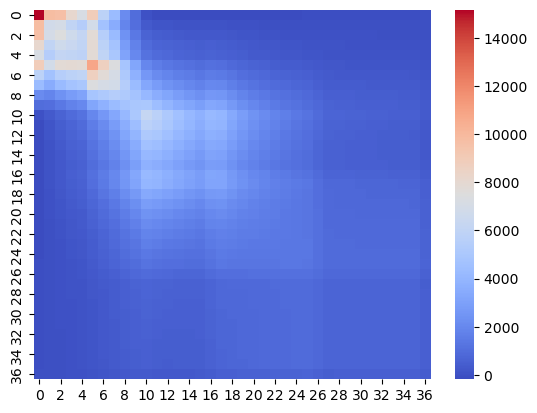

In [18]:
import seaborn as sns

sns.heatmap(C, cmap='coolwarm')

<Axes: >

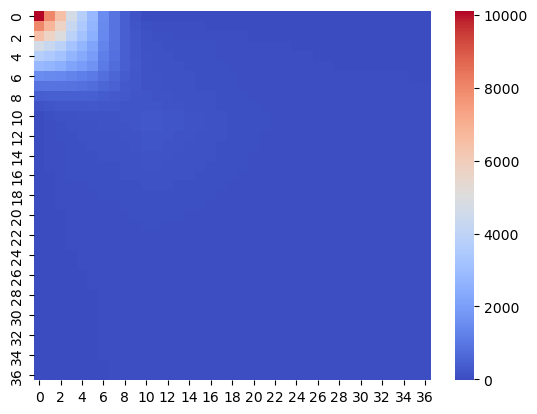

In [19]:
sns.heatmap(C_unwght, cmap='coolwarm')

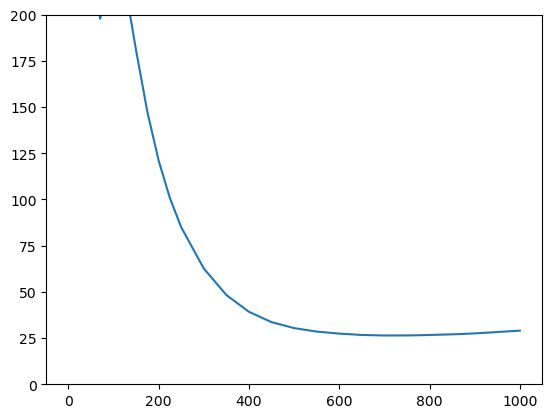

In [20]:
plt.ylim(0,200)
plt.plot(tamp.level.values,np.diag(C_unwght))

In [21]:
np.all(np.linalg.eigvalsh(C) > 0)

True

In [22]:
# Solve the eigenvalue problem
eigenvalues, eigenvectors = np.linalg.eigh(C)
# eigenvalues shape:  (37,)       ascending order, smallest first
# eigenvectors shape: (37, 37)    column j is the eigenvector for eigenvalue j

# Flip to descending order (EOF1 = most variance first)
eigenvalues  = eigenvalues[::-1]          # shape (37,)
eigenvectors = eigenvectors[:, ::-1]      # shape (37, 37), columns flipped

# Sanity checks
print(f"Eigenvalues (first 5): {eigenvalues[:5]}")
print(f"Sum of eigenvalues: {eigenvalues.sum():.4f}")
print(f"Total variance from diagonal: {np.diag(C).sum():.4f}")  # must match sum of eigenvalues

# Variance fractions
var_fractions = eigenvalues / eigenvalues.sum()
print(f"Variance explained by EOF1: {var_fractions[0]*100:.2f}%")
print(f"Variance explained by EOF2: {var_fractions[1]*100:.2f}%")
print(f"Variance explained by EOF1+2: {var_fractions[:2].sum()*100:.2f}%")

Eigenvalues (first 5): [64379.12388101 42569.71850911 10812.51008342  7973.38680203
  2027.72803529]
Sum of eigenvalues: 129421.5392
Total variance from diagonal: 129421.5392
Variance explained by EOF1: 49.74%
Variance explained by EOF2: 32.89%
Variance explained by EOF1+2: 82.64%


In [23]:
# Z_weighted is already A^(1/2) Z_m from Step 3, shape (37, 16059)
# eigenvectors shape: (37, 37), column j is EOF j

# Project: pc_j(t) = v_j . (A^(1/2) Z_m)
# eigenvectors.T shape: (37, 37), row j is v_j
# mass weighted TAM shape: (37, 16059)
# Result: (37, 16059) -- all PCs at once
PCs = eigenvectors.T @ tam_wgtd  # shape (n_modes, nt) = (37, 16059)


# Normalize to unit variance and mean center
PCs = PCs - PCs.mean(axis=1, keepdims=True)
PCs = PCs / PCs.std(axis=1, keepdims=True)  # each PC divided by its own std

# Verify
print(f"PC1 mean: {PCs[0].mean():.2e}")   # should be ~0 (machine epsilon)
print(f"PC2 mean: {PCs[1].mean():.2e}")
print(f"PC1 std:  {PCs[0].std():.6f}")    # should be exactly 1.0
print(f"PC2 std:  {PCs[1].std():.6f}")

PC1 mean: -2.10e-17
PC2 mean: 5.09e-18
PC1 std:  1.000000
PC2 std:  1.000000


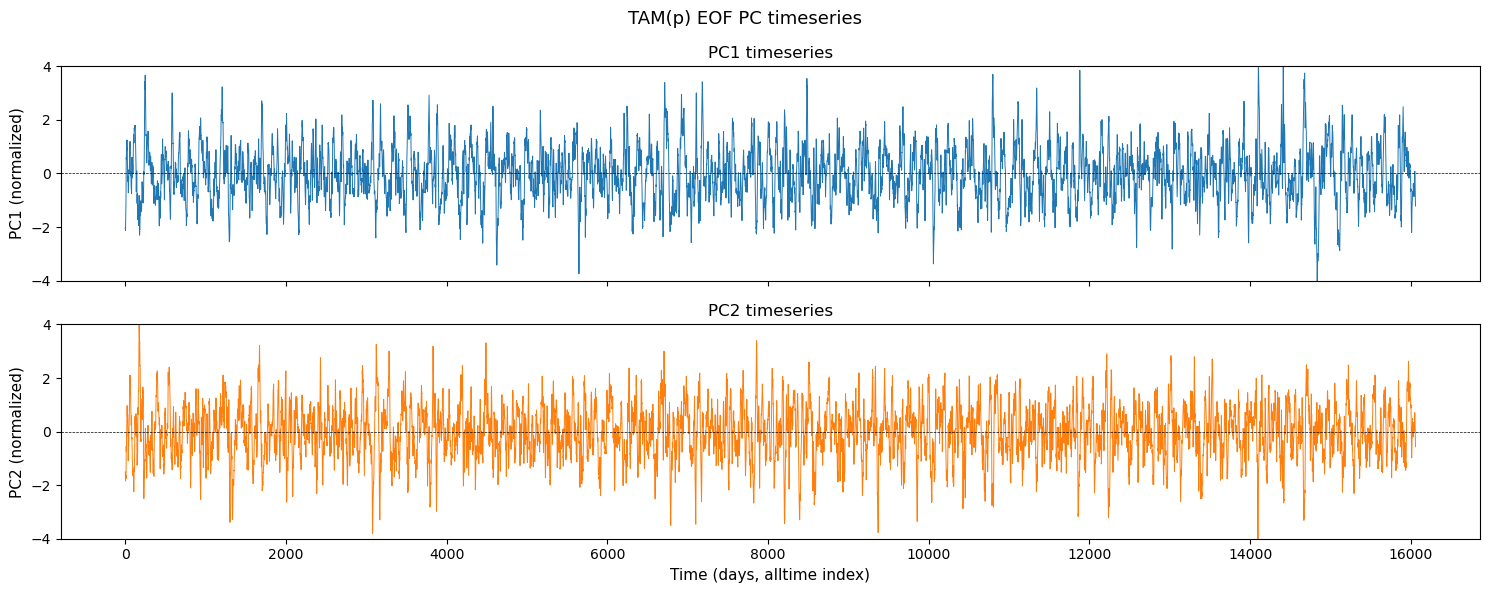

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(PCs[i], linewidth=0.7, color=f'C{i}')
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_ylabel(f'PC{i+1} (normalized)', fontsize=11)
    ax.set_title(f'PC{i+1} timeseries', fontsize=12)
    ax.set_ylim(-4, 4)

axes[1].set_xlabel('Time (days, alltime index)', fontsize=11)
plt.suptitle('TAM(p) EOF PC timeseries', fontsize=13)
plt.tight_layout()
#plt.savefig('TAMp_PC_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

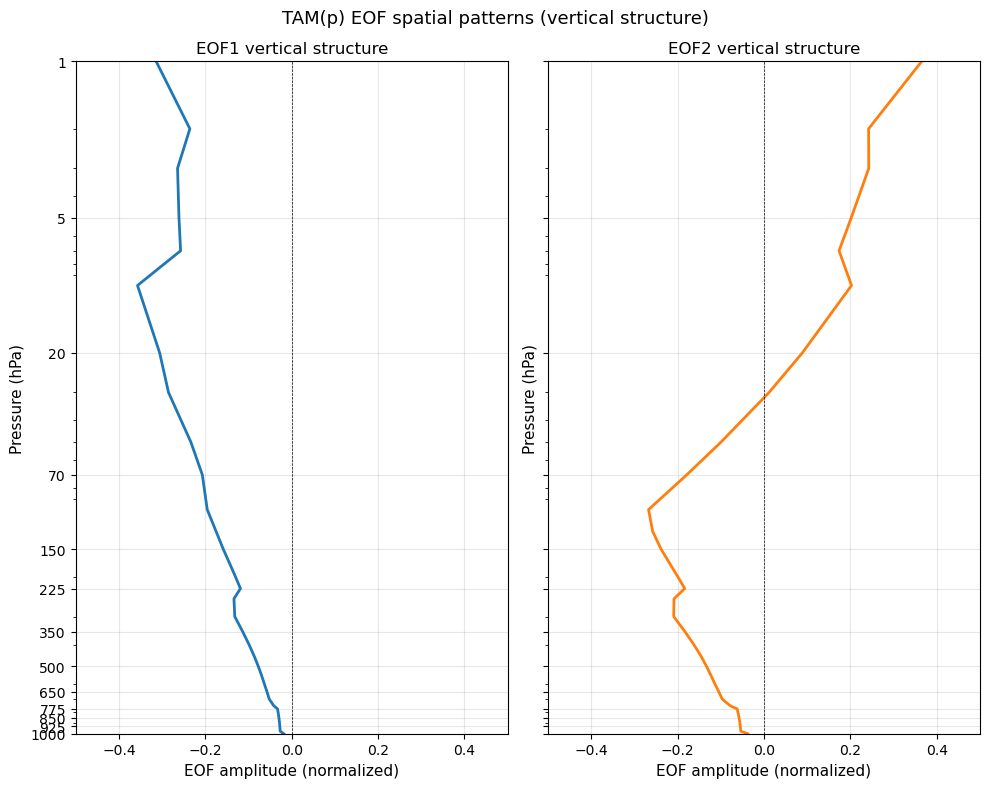

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8), sharey=True)

for i, ax in enumerate(axes):
    ax.plot(eigenvectors[:, i], levels, color=f'C{i}', linewidth=2)
    ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlabel('EOF amplitude (normalized)', fontsize=11)
    ax.set_title(f'EOF{i+1} vertical structure', fontsize=12)
    ax.set_xlim(-0.5, 0.5)
    ax.set_yscale('log')
    ax.set_ylim(1000, 1)        # explicitly set: 1000 hPa at bottom, 1 hPa at top
    ax.set_ylabel('Pressure (hPa)', fontsize=11)
    ax.set_yticks(levels[::3])
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.grid(True, alpha=0.3)

plt.suptitle('TAM(p) EOF spatial patterns (vertical structure)', fontsize=13)
plt.tight_layout()
#plt.savefig('TAMp_EOF_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

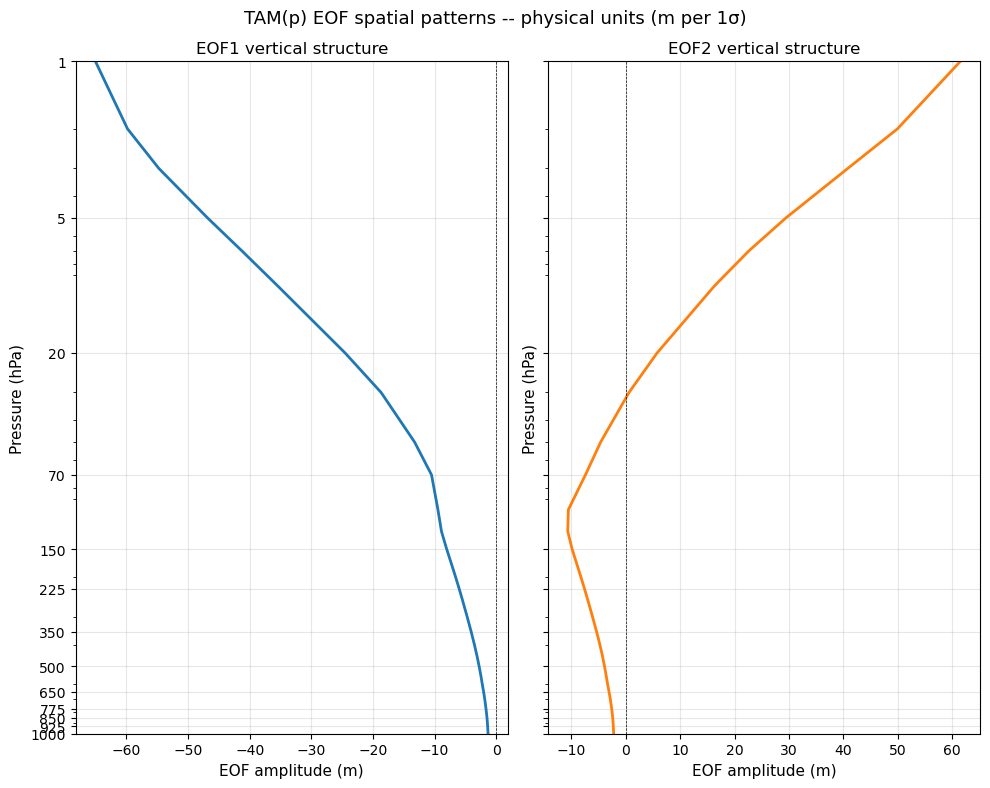

In [26]:
# Compute physical unit EOFs
Z_m_valsr = tamp.values  # shape (n_level, nt)
nt = Z_m_valsr.shape[1]

eof1_physicalr = (Z_m_valsr @ PCs[0]) / (nt)  # shape (n_level,), meters
eof2_physicalr = (Z_m_valsr @ PCs[1]) / (nt)  # shape (n_level,), meters

fig, axes = plt.subplots(1, 2, figsize=(10, 8), sharey=True)

for i, (ax, eof_phys) in enumerate(zip(axes, [eof1_physicalr, eof2_physicalr])):
    ax.plot(eof_phys, tamp.level.values, color=f'C{i}', linewidth=2)
    ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlabel('EOF amplitude (m)', fontsize=11)
    ax.set_title(f'EOF{i+1} vertical structure', fontsize=12)
    ax.set_yscale('log')
    ax.set_ylim(1000, 100)
    ax.set_ylabel('Pressure (hPa)', fontsize=11)
    ax.set_yticks(tamp.level.values[::3])
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.grid(True, alpha=0.3)

plt.suptitle('TAM(p) EOF spatial patterns -- physical units (m per 1σ)', fontsize=13)
plt.tight_layout()
#plt.savefig('TAMp_EOF_patterns_physical.png', dpi=300, bbox_inches='tight')
plt.show()

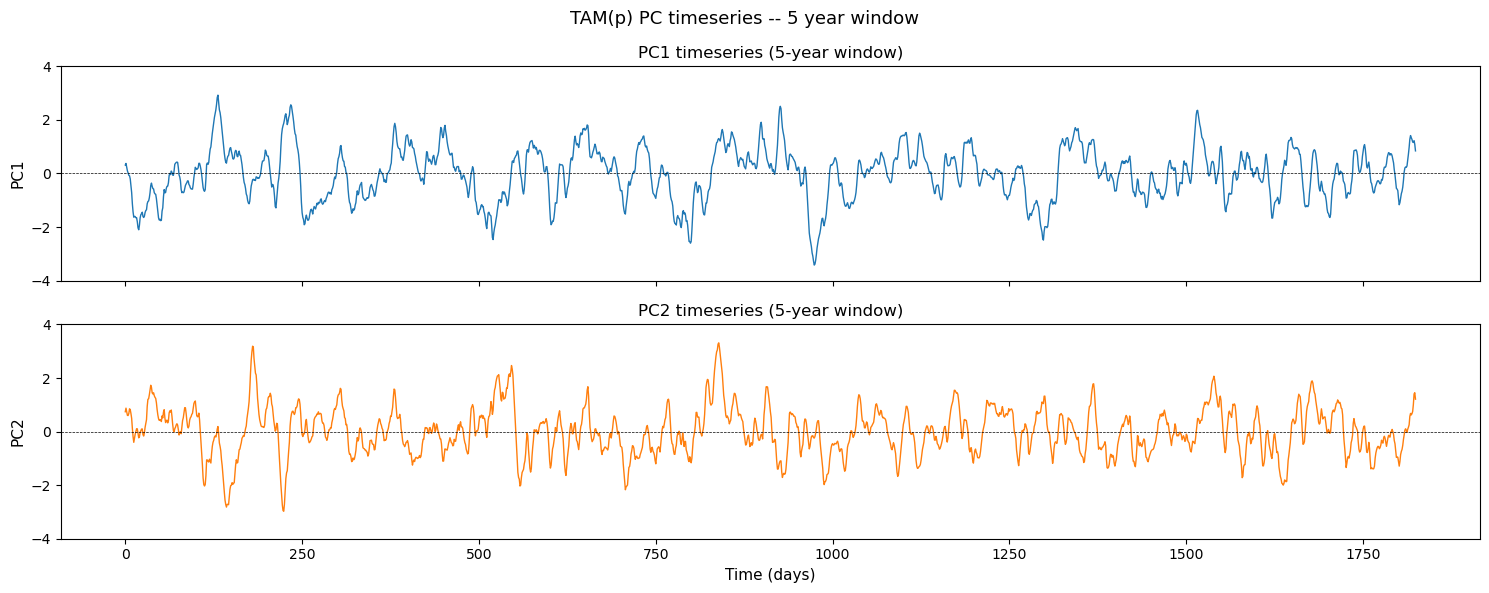

In [27]:
# Plot a 5 year window to see structure more clearly
# e.g. years 10-15 of the record (roughly days 3650-5475)
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

window = slice(3650, 5475)
for i, ax in enumerate(axes):
    ax.plot(PCs[i][window], linewidth=1.0, color=f'C{i}')
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_ylabel(f'PC{i+1}', fontsize=11)
    ax.set_title(f'PC{i+1} timeseries (5-year window)', fontsize=12)
    ax.set_ylim(-4, 4)

axes[1].set_xlabel('Time (days)', fontsize=11)
plt.suptitle('TAM(p) PC timeseries -- 5 year window', fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
# Flip sign of EOF1 and PC1 + EOF2, PC2
eigenvectors[:, 0] *= -1
PCs[0] *= -1

eigenvectors[:, 1] *= -1
PCs[1] *= -1

# careful with this cell by the way! 

In [29]:

print(f"PC1 vs TAM(850): {np.corrcoef(PCs[0], tam850.values)[0,1]:.4f}")
print(f"PC2 vs TAM(850): {np.corrcoef(PCs[1], tam850.values)[0,1]:.4f}")

PC1 vs TAM(850): 0.2894
PC2 vs TAM(850): 0.4580


In [11]:
def pc_lag_corr(pc1, pc2, max_lag):
    """
    Lag correlation between PC1 and PC2.
    Positive lag = PC1 leads PC2.
    No overlap correction needed -- timeseries length (16059) is vastly
    larger than max_lag so the reduction in overlap is negligible (<0.3%).
    PC1 and PC2 are assumed to be unit variance (std=1).
    
    Parameters
    ----------
    pc1, pc2 : np.ndarray (nt,)
    max_lag  : int -- maximum lag in days
    
    Returns
    -------
    lags : np.ndarray
    corr : np.ndarray
    """
    N = len(pc1)
    lags = np.arange(-max_lag, max_lag + 1)
    
    corr_raw = correlate(pc2, pc1, mode='full')
    center = len(corr_raw) // 2
    corr_raw = corr_raw[center - max_lag : center + max_lag + 1]
    
    # Simple normalization -- no overlap correction needed at this timeseries length
    corr = corr_raw / (N*np.std(pc1)*np.std(pc2))
    """
    for j, lag in enumerate(lags):
        n_overlap = N - abs(lag)
        corr[j] = corr_raw[j] / (np.std(pc1) * np.std(pc2) * n_overlap)
        """
    
    return lags, corr

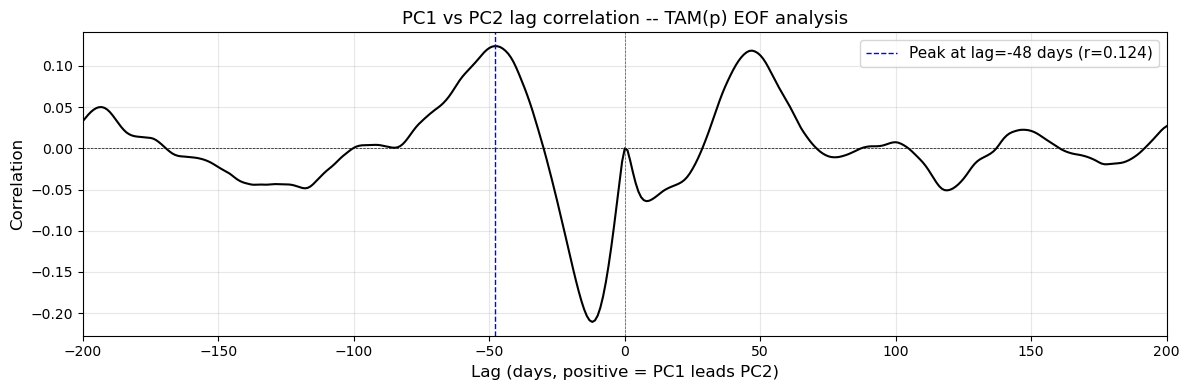

Peak correlation: 0.1241 at lag -48 days


In [50]:
lags, corr = pc_lag_corr(PCs[0], PCs[1], max_lag=200)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lags, corr, color='k', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='r', linewidth=0.5, linestyle='--')

# Mark the peak
peak_lag = lags[np.argmax(corr)]
peak_val = corr.max()
ax.axvline(peak_lag, color='b', linewidth=1, linestyle='--',
           label=f'Peak at lag={peak_lag} days (r={peak_val:.3f})')

ax.set_xlabel('Lag (days, positive = PC1 leads PC2)', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title('PC1 vs PC2 lag correlation -- TAM(p) EOF analysis', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-200, 200)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('TAMp_PC1_PC2_lagcorr.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Peak correlation: {peak_val:.4f} at lag {peak_lag} days")

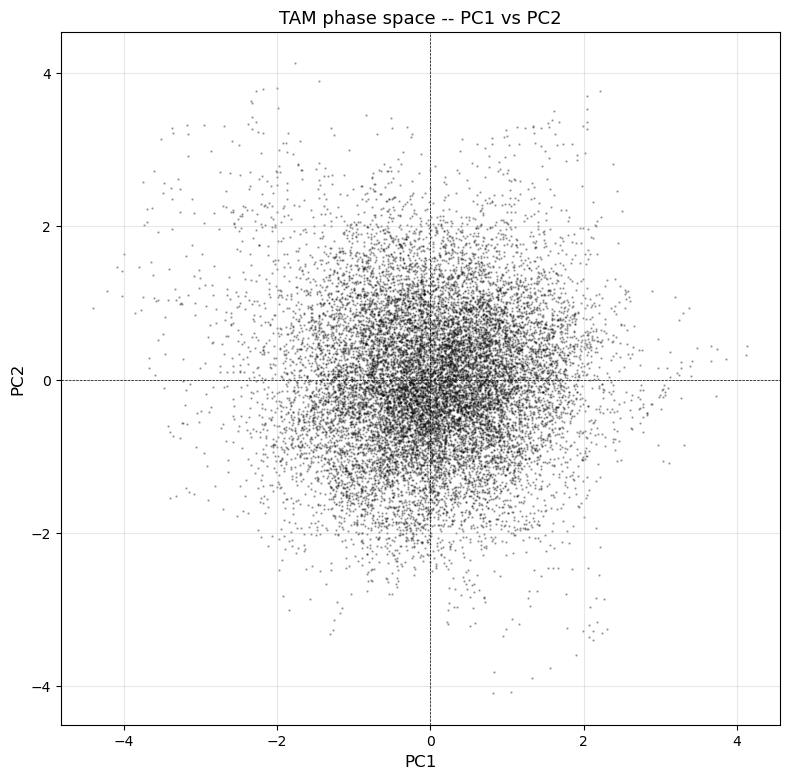

In [32]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(PCs[0], PCs[1], s=0.5, alpha=0.3, color='k')
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('TAM phase space -- PC1 vs PC2', fontsize=13)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 100-1000 hPa?

In [12]:
def weighted_cov_matrix(Z_m, p_top=0, p_bot=1000):
    """
    Computes the mass-weighted covariance matrix for EOF/PCA analysis.

    Parameters
    ----------
    Z_m   : xr.DataArray (level, alltime)
        Tropical mean GPH anomaly timeseries, highpass filtered.
        Levels must be ascending (1 -> 1000 hPa).
    p_top : float
        Top pressure boundary in hPa (default 0 hPa)
    p_bot : float
        Bottom pressure boundary in hPa (default 1000 hPa)

    Returns
    -------
    C         : np.ndarray (n_level, n_level)
        Mass-weighted covariance matrix
    A_half    : np.ndarray (n_level,)
        Square root of diagonal mass weighting matrix (sqrt of delta_p)
    Z_weighted : np.ndarray (n_level, nt)
        A^(1/2) Z_m -- mass-weighted data matrix, needed for PC computation
    """
    # Extract numpy arrays
    Z_m_vals = Z_m.values                # shape (n_level, nt)
    levels   = Z_m.level.values          # shape (n_level,), ascending
    nt       = Z_m_vals.shape[1]

    # Step 1: compute half-levels (midpoints between adjacent level centers)
    half_levels = 0.5 * (levels[:-1] + levels[1:])  # shape (n_level - 1,)

    # Step 2: add pressure boundaries
    half_levels_full = np.concatenate([[p_top], half_levels, [p_bot]])  # shape (n_level + 1,)

    # Step 3: delta_p -- thickness of layer owned by each level
    delta_p = np.diff(half_levels_full)   # shape (n_level,), all positive (ascending)

    # Sanity check
    expected_total = p_bot - p_top
    assert np.isclose(delta_p.sum(), expected_total), \
        f"delta_p sum {delta_p.sum():.2f} != expected {expected_total:.2f} hPa"

    # Step 4: A^(1/2) diagonal
    A_half = np.sqrt(delta_p)             # shape (n_level,)

    # Step 5: mass-weighted data matrix A^(1/2) Z_m
    Z_weighted = A_half[:, np.newaxis] * Z_m_vals   # shape (n_level, nt)

    # Step 6: covariance matrix
    C = (Z_weighted @ Z_weighted.T) / (nt - 1)      # shape (n_level, n_level)

    # Sanity checks
    assert np.allclose(C, C.T),         "C is not symmetric -- check input data"
    assert np.all(np.diag(C) > 0),     "C has non-positive diagonal entries"

    return C, A_half, Z_weighted

In [13]:
# Full column
#C_full, A_half_full, Z_weighted_full = weighted_cov_matrix(tamp)

# Troposphere only (200-1000 hPa)
C_trop, A_half_trop, tamwgt_trop = weighted_cov_matrix(tam_trop, p_top=100, p_bot=1000)

In [12]:
sns.heatmap(C_trop, cmap='coolwarm')

NameError: name 'sns' is not defined

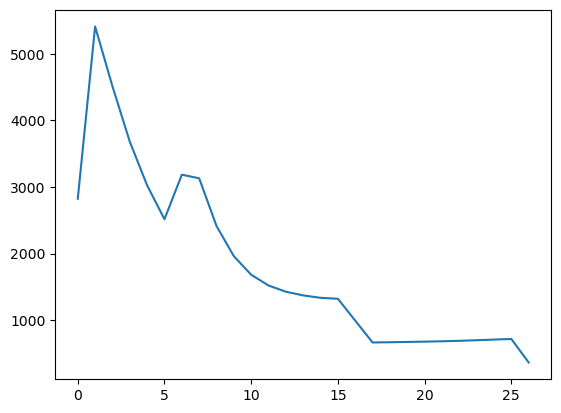

In [36]:
plt.plot(np.diag(C_trop))

In [14]:
tam_trop.level.values

array([ 100.,  125.,  150.,  175.,  200.,  225.,  250.,  300.,  350.,
        400.,  450.,  500.,  550.,  600.,  650.,  700.,  750.,  775.,
        800.,  825.,  850.,  875.,  900.,  925.,  950.,  975., 1000.])

In [15]:
# Solve the eigenvalue problem
evaltrop, evectrop = np.linalg.eigh(C_trop)
# eigenvalues shape:  (37,)       ascending order, smallest first
# eigenvectors shape: (37, 37)    column j is the eigenvector for eigenvalue j

# Flip to descending order (EOF1 = most variance first)
evaltrop  = evaltrop[::-1]          # shape (37,)
evectrop = evectrop[:, ::-1]      # shape (37, 37), columns flipped

# Sanity checks
print(f"Eigenvalues (first 5): {evaltrop[:5]}")
print(f"Sum of eigenvalues: {evaltrop.sum():.4f}")
print(f"Total variance from diagonal: {np.diag(C_trop).sum():.4f}")  # must match sum of eigenvalues

# Variance fractions
var_fractions_trop = evaltrop / evaltrop.sum()
print(f"Variance explained by EOF1: {var_fractions_trop[0]*100:.2f}%")
print(f"Variance explained by EOF2: {var_fractions_trop[1]*100:.2f}%")
print(f"Variance explained by EOF1+2: {var_fractions_trop[:2].sum()*100:.2f}%")

Eigenvalues (first 5): [38743.78966357  9444.37379739   391.99016784   128.48407714
    67.81791031]
Sum of eigenvalues: 48827.6081
Total variance from diagonal: 48827.6081
Variance explained by EOF1: 79.35%
Variance explained by EOF2: 19.34%
Variance explained by EOF1+2: 98.69%


In [16]:
PCstrop = evectrop.T @ tamwgt_trop  # shape (n_modes, nt) = (37, 16059)


# Normalize to unit variance and mean center
PCstrop = PCstrop - PCstrop.mean(axis=1, keepdims=True)
PCstrop = PCstrop / PCstrop.std(axis=1, keepdims=True)  # each PC divided by its own std

# Verify
print(f"PC1 mean: {PCstrop[0].mean():.2e}")   # should be ~0 (machine epsilon)
print(f"PC2 mean: {PCstrop[1].mean():.2e}")
print(f"PC1 std:  {PCstrop[0].std():.6f}")    # should be exactly 1.0
print(f"PC2 std:  {PCstrop[1].std():.6f}")

PC1 mean: -1.33e-17
PC2 mean: 9.07e-18
PC1 std:  1.000000
PC2 std:  1.000000


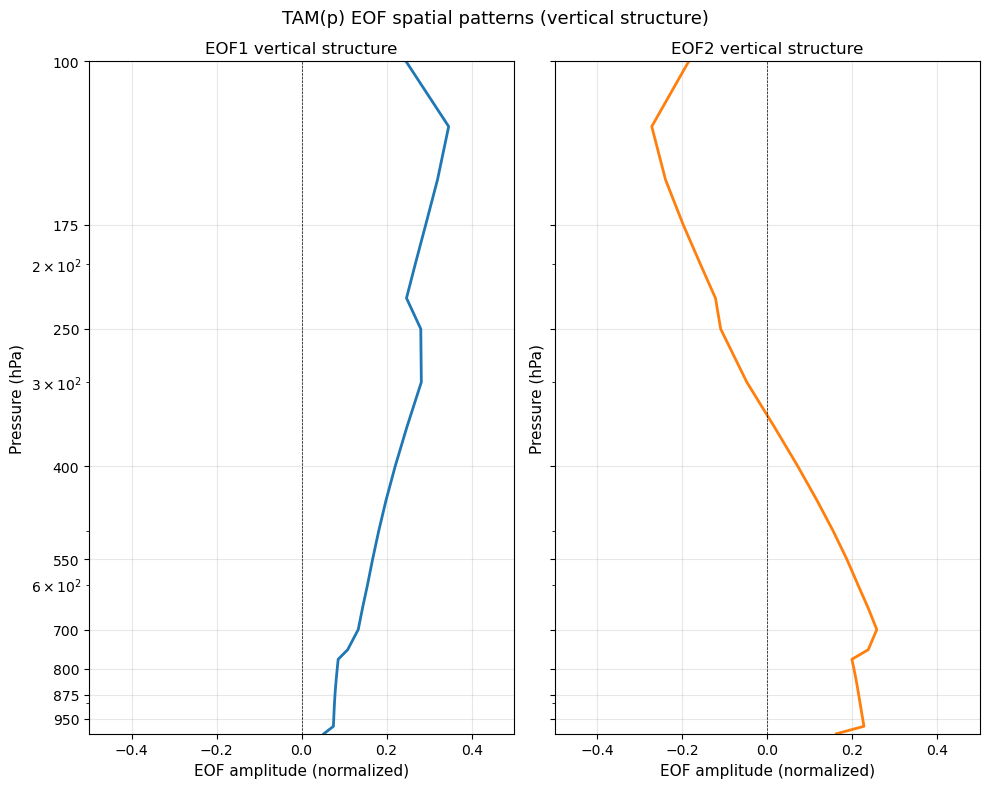

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8), sharey=True)

for i, ax in enumerate(axes):
    ax.plot(evectrop[:, i], tam_trop.level.values, color=f'C{i}', linewidth=2)
    ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlabel('EOF amplitude (normalized)', fontsize=11)
    ax.set_title(f'EOF{i+1} vertical structure', fontsize=12)
    ax.set_xlim(-0.5, 0.5)
    ax.set_yscale('log')
    ax.set_ylim(1000, 100)        
    ax.set_ylabel('Pressure (hPa)', fontsize=11)
    ax.set_yticks(tam_trop.level.values[::3])
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.grid(True, alpha=0.3)

plt.suptitle('TAM(p) EOF spatial patterns (vertical structure)', fontsize=13)
plt.tight_layout()
plt.savefig('TAMp_EOFnormpatterns.png', dpi=300, bbox_inches='tight')
plt.show()

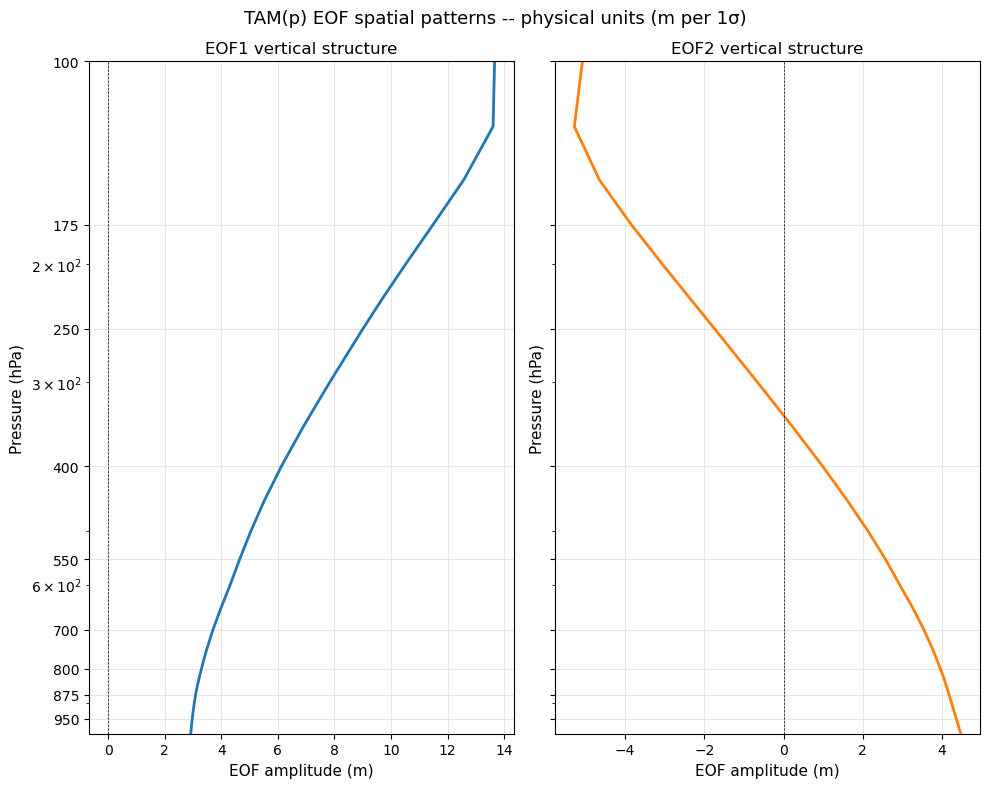

In [19]:
# Compute physical unit EOFs
Z_m_vals = tam_trop.values 
nt = Z_m_vals.shape[1]

eof1_physical = (Z_m_vals @ PCstrop[0]) / (nt)  
eof2_physical = (Z_m_vals @ PCstrop[1]) / (nt)  

fig, axes = plt.subplots(1, 2, figsize=(10, 8), sharey=True)

for i, (ax, eof_phys) in enumerate(zip(axes, [eof1_physical, eof2_physical])):
    ax.plot(eof_phys, tam_trop.level.values, color=f'C{i}', linewidth=2)
    ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlabel('EOF amplitude (m)', fontsize=11)
    ax.set_title(f'EOF{i+1} vertical structure', fontsize=12)
    ax.set_yscale('log')
    ax.set_ylim(1000, 100)
    ax.set_ylabel('Pressure (hPa)', fontsize=11)
    ax.set_yticks(tam_trop.level.values[::3])
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.grid(True, alpha=0.3)

plt.suptitle('TAM(p) EOF spatial patterns -- physical units (m per 1σ)', fontsize=13)
plt.tight_layout()
#plt.savefig('TAMp_EOF_patterns_physical.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Flip sign of EOF1 and PC1 + EOF2, PC2
evectrop[:, 0] *= -1
PCstrop[0] *= -1

evectrop[:, 1] *= -1
PCstrop[1] *= -1

# careful with this cell by the way! 
print(f"PC1 vs TAM(850): {np.corrcoef(PCstrop[0], tam850.values)[0,1]:.4f}")
print(f"PC2 vs TAM(850): {np.corrcoef(PCstrop[1], tam850.values)[0,1]:.4f}")

PC1 vs TAM(850): 0.6052
PC2 vs TAM(850): 0.7903


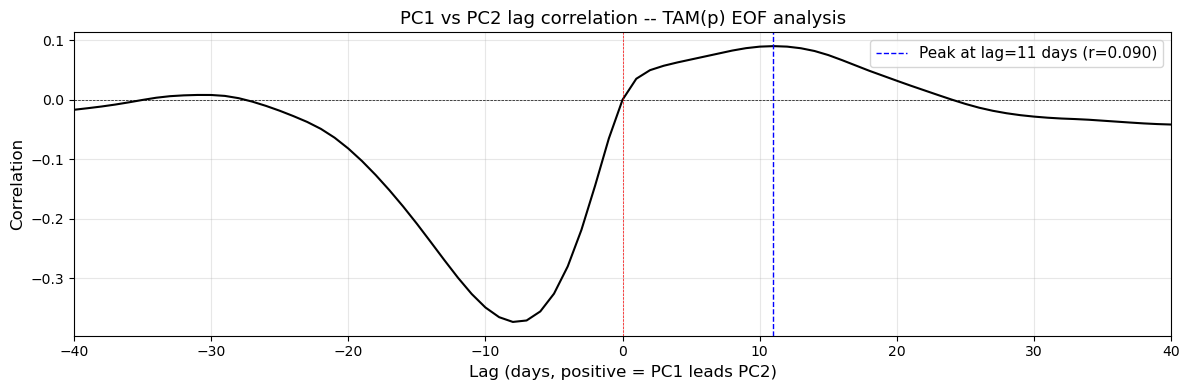

Peak correlation: 0.0901 at lag 11 days


In [20]:
lagstrop, corrtrop = pc_lag_corr(PCstrop[0], PCstrop[1], max_lag=100)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lagstrop, corrtrop, color='k', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='r', linewidth=0.5, linestyle='--')

# Mark the peak
peak_lag = lagstrop[np.argmax(corrtrop)]
peak_val = corrtrop.max()
ax.axvline(peak_lag, color='b', linewidth=1, linestyle='--',
           label=f'Peak at lag={peak_lag} days (r={peak_val:.3f})')

ax.set_xlabel('Lag (days, positive = PC1 leads PC2)', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title('PC1 vs PC2 lag correlation -- TAM(p) EOF analysis', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-40, 40)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('TAMp_PC1_PC2_lagcorr.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Peak correlation: {peak_val:.4f} at lag {peak_lag} days")

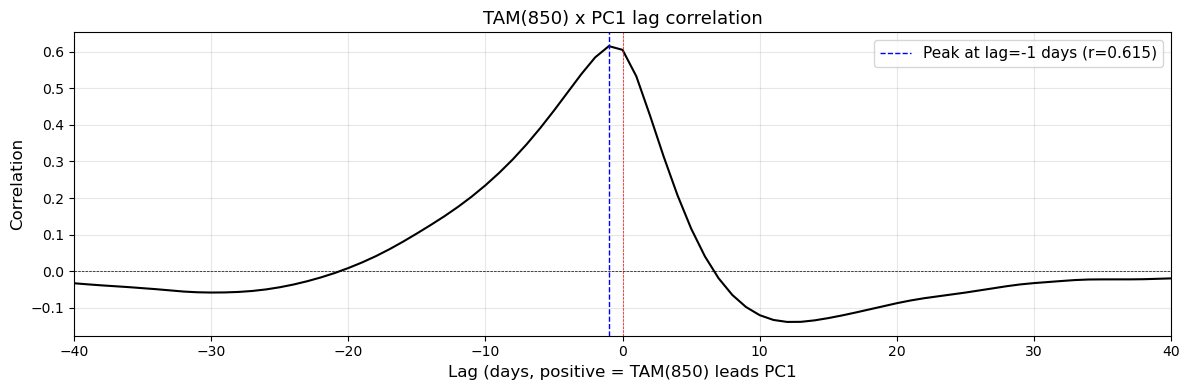

Peak correlation: 0.6154 at lag -1 days


In [22]:
lagstrop, corrtrop = pc_lag_corr(tam850.values, PCstrop[0], max_lag=100)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lagstrop, corrtrop, color='k', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='r', linewidth=0.5, linestyle='--')

# Mark the peak
peak_lag = lagstrop[np.argmax(corrtrop)]
peak_val = corrtrop.max()
ax.axvline(peak_lag, color='b', linewidth=1, linestyle='--',
           label=f'Peak at lag={peak_lag} days (r={peak_val:.3f})')

ax.set_xlabel('Lag (days, positive = TAM(850) leads PC1', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title('TAM(850) x PC1 lag correlation', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-40, 40)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('TAM850_PC1_lagcorr.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Peak correlation: {peak_val:.4f} at lag {peak_lag} days")

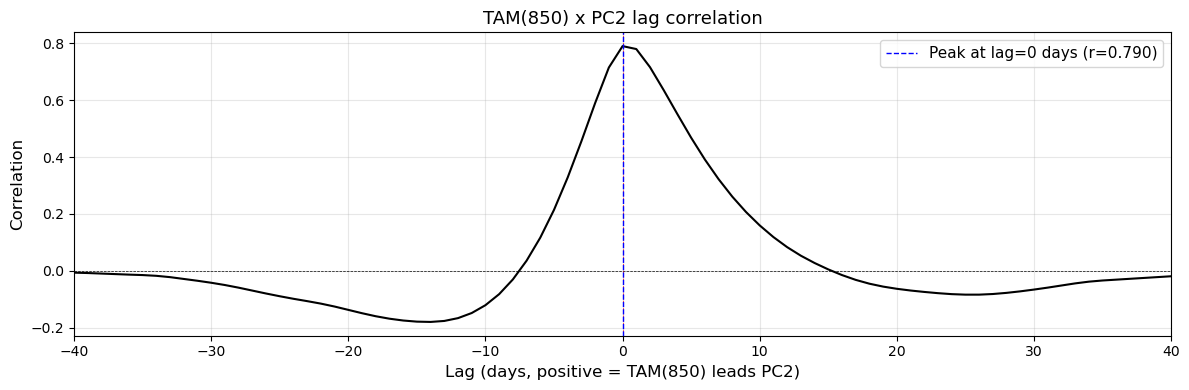

Peak correlation: 0.7903 at lag 0 days


In [23]:
lagstrop, corrtrop = pc_lag_corr(tam850.values, PCstrop[1],max_lag=100)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lagstrop, corrtrop, color='k', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='r', linewidth=0.5, linestyle='--')

# Mark the peak
peak_lag = lagstrop[np.argmax(corrtrop)]
peak_val = corrtrop.max()
ax.axvline(peak_lag, color='b', linewidth=1, linestyle='--',
           label=f'Peak at lag={peak_lag} days (r={peak_val:.3f})')

ax.set_xlabel('Lag (days, positive = TAM(850) leads PC2)', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title('TAM(850) x PC2 lag correlation', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-40, 40)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('TAM850_PC2_lagcorr.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Peak correlation: {peak_val:.4f} at lag {peak_lag} days")

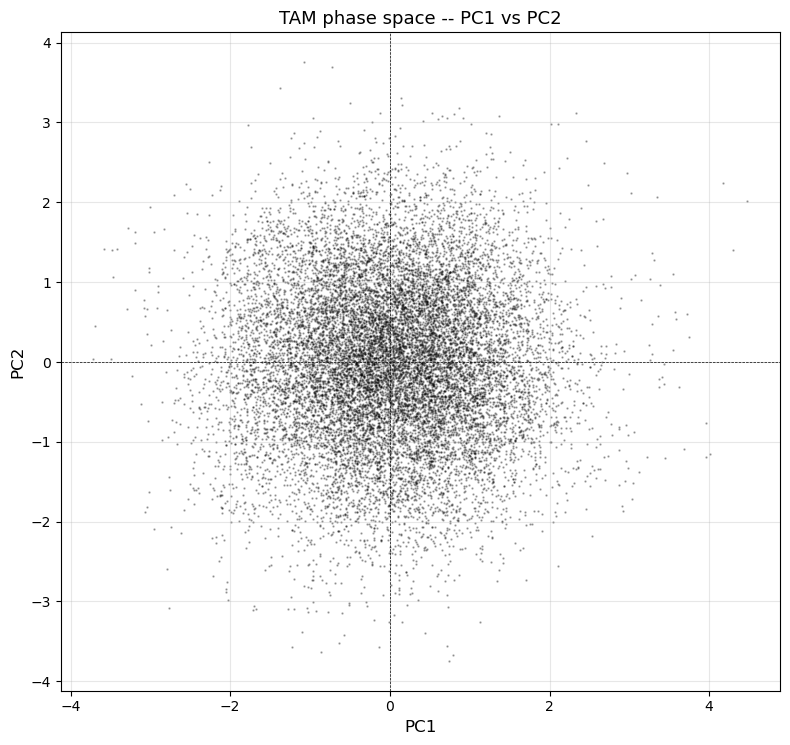

In [37]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(PCstrop[0], PCstrop[1], s=0.5, alpha=0.3, color='k')
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('TAM phase space -- PC1 vs PC2', fontsize=13)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phasespacetrop.png', dpi=300, bbox_inches='tight')
plt.show()

### 200 hPa - 1000 hPa

In [80]:
tam_trop2 = tam_trop.sel(level=slice(200,1000))

In [81]:
# 200 - 1000
C_trop2, A_half_trop2, tamwgt_trop2 = weighted_cov_matrix(tam_trop2, p_top=200, p_bot=1000)

<Axes: >

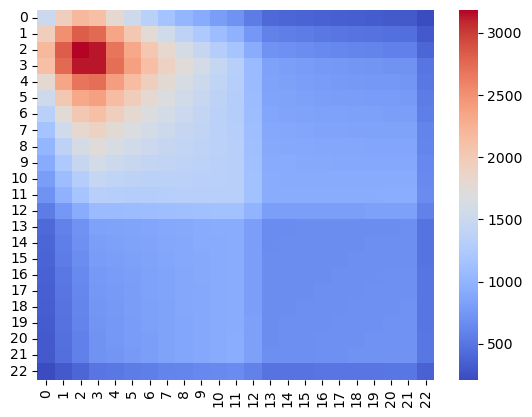

In [82]:
sns.heatmap(C_trop2, cmap='coolwarm')

In [83]:
# Solve the eigenvalue problem
evaltrop2, evectrop2 = np.linalg.eigh(C_trop2)
# eigenvalues shape:  (37,)       ascending order, smallest first
# eigenvectors shape: (37, 37)    column j is the eigenvector for eigenvalue j

# Flip to descending order (EOF1 = most variance first)
evaltrop2  = evaltrop2[::-1]          # shape (37,)
evectrop2 = evectrop2[:, ::-1]      # shape (37, 37), columns flipped

# Sanity checks
print(f"Eigenvalues (first 5): {evaltrop2[:5]}")
print(f"Sum of eigenvalues: {evaltrop2.sum():.4f}")
print(f"Total variance from diagonal: {np.diag(C_trop2).sum():.4f}")  # must match sum of eigenvalues

# Variance fractions
var_fractions_trop2 = evaltrop2 / evaltrop2.sum()
print(f"Variance explained by EOF1: {var_fractions_trop2[0]*100:.2f}%")
print(f"Variance explained by EOF2: {var_fractions_trop2[1]*100:.2f}%")
print(f"Variance explained by EOF1+2: {var_fractions_trop2[:2].sum()*100:.2f}%")

Eigenvalues (first 5): [2.49900186e+04 5.70034191e+03 1.22900714e+02 4.98113530e+01
 1.46027459e+01]
Sum of eigenvalues: 30888.0549
Total variance from diagonal: 30888.0549
Variance explained by EOF1: 80.91%
Variance explained by EOF2: 18.45%
Variance explained by EOF1+2: 99.36%


In [84]:
PCstrop2 = evectrop2.T @ tamwgt_trop2  # shape (n_modes, nt) = (37, 16059)


# Normalize to unit variance and mean center
PCstrop2 = PCstrop2 - PCstrop2.mean(axis=1, keepdims=True)
PCstrop2 = PCstrop2 / PCstrop2.std(axis=1, keepdims=True)  # each PC divided by its own std

# Verify
print(f"PC1 mean: {PCstrop2[0].mean():.2e}")   # should be ~0 (machine epsilon)
print(f"PC2 mean: {PCstrop2[1].mean():.2e}")
print(f"PC1 std:  {PCstrop2[0].std():.6f}")    # should be exactly 1.0
print(f"PC2 std:  {PCstrop2[1].std():.6f}")

PC1 mean: 2.04e-17
PC2 mean: 3.87e-18
PC1 std:  1.000000
PC2 std:  1.000000


In [95]:
evectrop2[:, 0] *= -1
PCstrop2[0] *= -1

evectrop2[:, 1] *= -1
PCstrop2[1] *= -1

# careful with this cell by the way! 
print(f"PC1 vs TAM(850): {np.corrcoef(PCstrop2[0], tam850.values)[0,1]:.4f}")
print(f"PC2 vs TAM(850): {np.corrcoef(PCstrop2[1], tam850.values)[0,1]:.4f}")

PC1 vs TAM(850): 0.8134
PC2 vs TAM(850): 0.5776


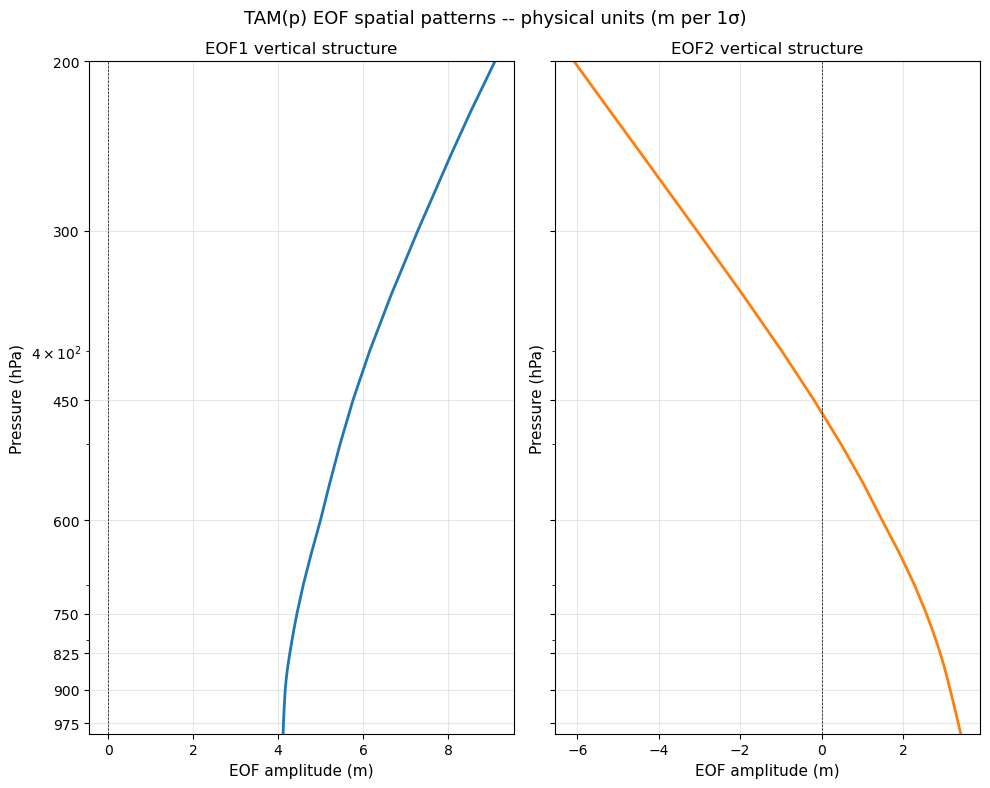

In [96]:
# Compute physical unit EOFs
Z_m_vals2 = tam_trop2.values 
nt2 = Z_m_vals2.shape[1]

eof1_physical2 = (Z_m_vals2 @ PCstrop2[0]) / (nt2)  
eof2_physical2 = (Z_m_vals2 @ PCstrop2[1]) / (nt2)  

fig, axes = plt.subplots(1, 2, figsize=(10, 8), sharey=True)

for i, (ax, eof_phys2) in enumerate(zip(axes, [eof1_physical2, eof2_physical2])):
    ax.plot(eof_phys2, tam_trop2.level.values, color=f'C{i}', linewidth=2)
    ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlabel('EOF amplitude (m)', fontsize=11)
    ax.set_title(f'EOF{i+1} vertical structure', fontsize=12)
    ax.set_yscale('log')
    ax.set_ylim(1000, 200)
    ax.set_ylabel('Pressure (hPa)', fontsize=11)
    ax.set_yticks(tam_trop2.level.values[::3])
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.grid(True, alpha=0.3)

plt.suptitle('TAM(p) EOF spatial patterns -- physical units (m per 1σ)', fontsize=13)
plt.tight_layout()
#plt.savefig('TAMp_EOF_patterns_physical.png', dpi=300, bbox_inches='tight')
plt.show()

In [97]:
np.corrcoef(PCstrop[0], PCstrop2[0])

array([[1.        , 0.95188114],
       [0.95188114, 1.        ]])

In [98]:
np.corrcoef(PCstrop[1], PCstrop2[1])

array([[1.        , 0.94476087],
       [0.94476087, 1.        ]])

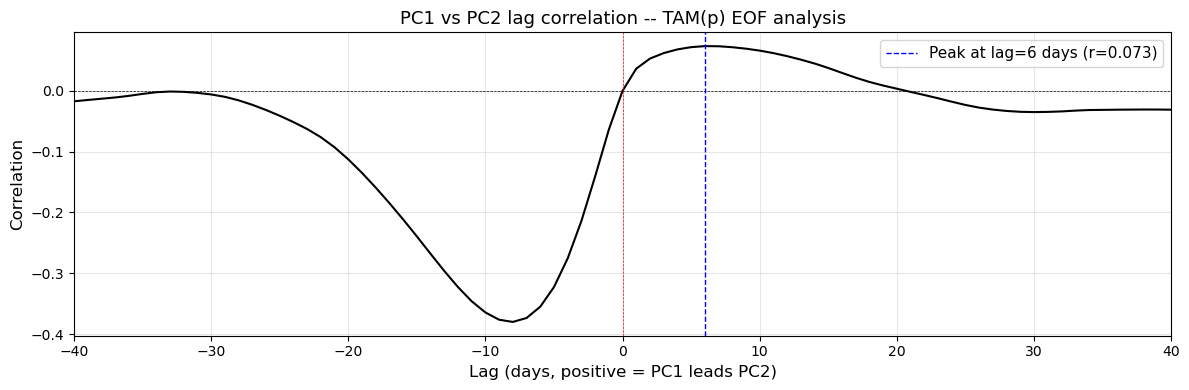

Peak correlation: 0.0734 at lag 6 days


In [99]:
lagstrop2, corrtrop2 = pc_lag_corr(PCstrop2[0], PCstrop2[1], max_lag=100)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lagstrop2, corrtrop2, color='k', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='r', linewidth=0.5, linestyle='--')

# Mark the peak
peak_lag2 = lagstrop2[np.argmax(corrtrop2)]
peak_val2 = corrtrop2.max()
ax.axvline(peak_lag2, color='b', linewidth=1, linestyle='--',
           label=f'Peak at lag={peak_lag2} days (r={peak_val2:.3f})')

ax.set_xlabel('Lag (days, positive = PC1 leads PC2)', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title('PC1 vs PC2 lag correlation -- TAM(p) EOF analysis', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-40, 40)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('TAMp_PC1_PC2_lagcorr.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Peak correlation: {peak_val2:.4f} at lag {peak_lag2} days")

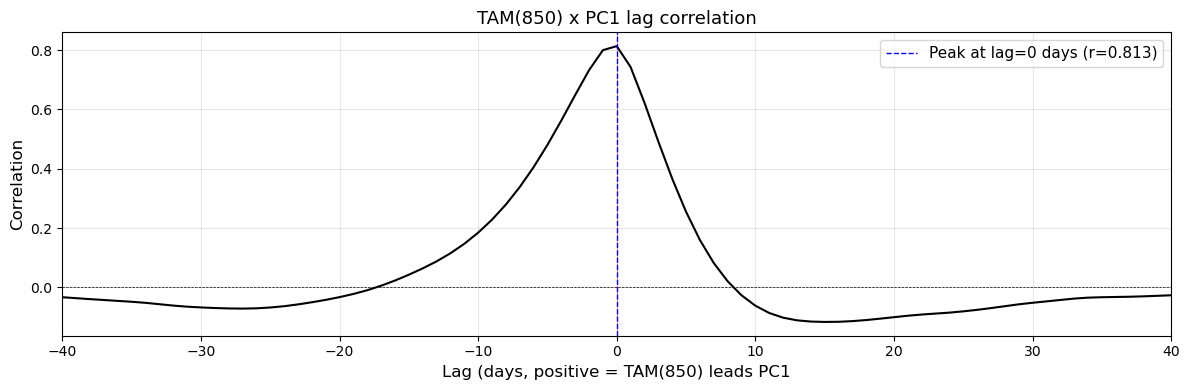

Peak correlation: 0.8134 at lag 0 days


In [100]:
lagstrop21, corrtrop21 = pc_lag_corr(tam850.values, PCstrop2[0], max_lag=100)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lagstrop21, corrtrop21, color='k', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='r', linewidth=0.5, linestyle='--')

# Mark the peak
peak_lag21 = lagstrop21[np.argmax(corrtrop21)]
peak_val21 = corrtrop21.max()
ax.axvline(peak_lag21, color='b', linewidth=1, linestyle='--',
           label=f'Peak at lag={peak_lag21} days (r={peak_val21:.3f})')

ax.set_xlabel('Lag (days, positive = TAM(850) leads PC1', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title('TAM(850) x PC1 lag correlation', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-40, 40)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('TAM850_PC1_lagcorr.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Peak correlation: {peak_val21:.4f} at lag {peak_lag21} days")

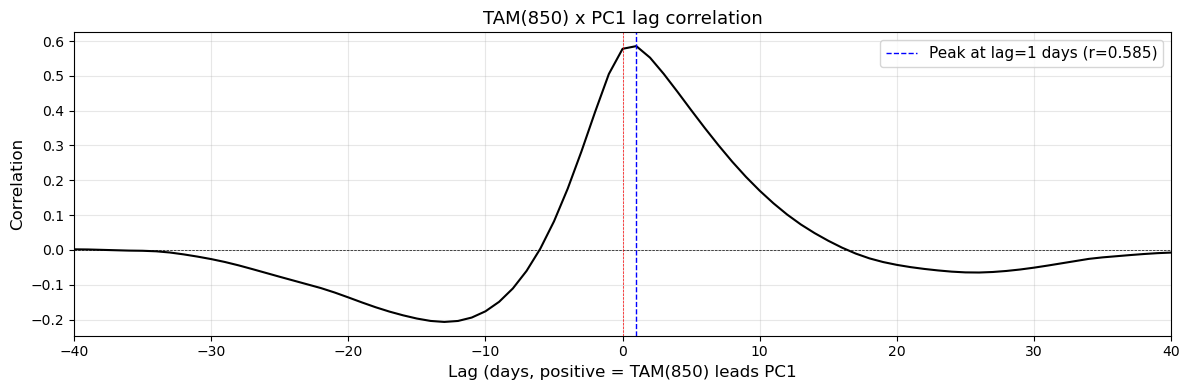

Peak correlation: 0.5853 at lag 1 days


In [102]:
lagstrop22, corrtrop22 = pc_lag_corr(tam850.values, PCstrop2[1], max_lag=100)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lagstrop22, corrtrop22, color='k', linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='r', linewidth=0.5, linestyle='--')

# Mark the peak
peak_lag22 = lagstrop22[np.argmax(corrtrop22)]
peak_val22 = corrtrop22.max()
ax.axvline(peak_lag22, color='b', linewidth=1, linestyle='--',
           label=f'Peak at lag={peak_lag22} days (r={peak_val22:.3f})')

ax.set_xlabel('Lag (days, positive = TAM(850) leads PC1', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title('TAM(850) x PC2 lag correlation', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-40, 40)
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('TAM850_PC1_lagcorr.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Peak correlation: {peak_val22:.4f} at lag {peak_lag22} days")

## 100 - 1000 hPa Phase Space Analysis

In [25]:
# Phase angle: shape (16059,), degrees in [-180, 180]
phi = np.degrees(np.arctan2(PCstrop[1], PCstrop[0]))

# Amplitude: shape (16059,)
A = np.sqrt(PCstrop[0]**2 + PCstrop[1]**2)

print(f"Phase angle range: {phi.min():.2f} to {phi.max():.2f} degrees")
print(f"Amplitude range: {A.min():.4f} to {A.max():.4f}")
print(f"Amplitude mean: {A.mean():.4f}")

Phase angle range: -179.97 to 180.00 degrees
Amplitude range: 0.0145 to 4.9089
Amplitude mean: 1.2504


In [26]:
# Phase borders
borders = np.arange(-180, 181, 45) - 22.5  
# [-202.5, -157.5, -112.5, -67.5, -22.5, 22.5, 67.5, 112.5, 157.5, 202.5]

# Wrap phi to [0, 360) for clean binning
phi_wrapped = phi % 360  # [0, 360)
"""
borders_wrapped = np.arange(0, 361, 45)  # [0, 45, 90, ..., 360]

# Assign phase 1-8 to each day
phase = np.digitize(phi_wrapped, borders_wrapped)  # 1-8
phase = np.where(phase == 9, 1, phase)  # wrap 360 back to phase 1
"""
borders_wrapped = np.arange(22.5, 360, 45)  
# [22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5]

phase = np.digitize(phi_wrapped, borders_wrapped) + 1
# digitize returns 0-7, so +1 gives 1-8
# phase 1: phi_wrapped < 22.5 OR phi_wrapped >= 337.5 (wrap around)
phase = np.where(phase == 9, 1, phase)
# Quick check
for p in range(1, 9):
    n_days = np.sum(phase == p)
    print(f"Phase {p}: {n_days} days ({n_days/len(phase)*100:.1f}%)")

Phase 1: 2032 days (12.7%)
Phase 2: 2066 days (12.9%)
Phase 3: 1968 days (12.3%)
Phase 4: 2040 days (12.7%)
Phase 5: 2015 days (12.5%)
Phase 6: 1962 days (12.2%)
Phase 7: 1964 days (12.2%)
Phase 8: 2012 days (12.5%)


In [27]:
# Get year coordinate from tamp_trop
years_coord = tam_trop.alltime.coords['year'].values  # shape (16059,)

# Mean amplitude per year
for y in range(1979, 2024):
    mask = years_coord == y
    print(f"{y}: mean amplitude = {A[mask].mean():.3f}")

1979: mean amplitude = 1.467
1980: mean amplitude = 1.088
1981: mean amplitude = 1.073
1982: mean amplitude = 1.362
1983: mean amplitude = 1.343
1984: mean amplitude = 1.411
1985: mean amplitude = 1.185
1986: mean amplitude = 1.261
1987: mean amplitude = 1.149
1988: mean amplitude = 1.163
1989: mean amplitude = 1.239
1990: mean amplitude = 1.190
1991: mean amplitude = 1.317
1992: mean amplitude = 1.127
1993: mean amplitude = 1.281
1994: mean amplitude = 1.101
1995: mean amplitude = 1.259
1996: mean amplitude = 1.310
1997: mean amplitude = 1.470
1998: mean amplitude = 1.463
1999: mean amplitude = 1.182
2000: mean amplitude = 1.181
2001: mean amplitude = 1.304
2002: mean amplitude = 1.359
2003: mean amplitude = 1.078
2004: mean amplitude = 1.109
2005: mean amplitude = 1.366
2006: mean amplitude = 1.373
2007: mean amplitude = 1.368
2008: mean amplitude = 1.215
2009: mean amplitude = 1.244
2010: mean amplitude = 1.191
2011: mean amplitude = 1.103
2012: mean amplitude = 1.167
2013: mean amp

In [20]:
tam_trop

<xarray.DataArray (level: 27, alltime: 16059)> Size: 3MB
array([[38.05019536, 39.37632506, 39.66574127, ..., 12.85292159,
        16.37747461, 16.96054609],
       [39.62171283, 40.13852626, 40.06901215, ..., 12.85243298,
        16.26992787, 16.93178459],
       [35.96836353, 36.08388454, 35.59874445, ..., 12.22255114,
        15.60280231, 16.10831899],
       ...,
       [ 5.30229339,  8.48012589, 10.6839901 , ..., -0.95433639,
         1.99738667,  4.67921951],
       [ 5.17935052,  8.40825292, 10.66603663, ..., -0.97108668,
         1.99780526,  4.75665009],
       [ 5.08906453,  8.36059797, 10.64413607, ..., -1.00507539,
         1.98139355,  4.82900243]])
Coordinates:
  * level    (level) float64 216B 100.0 125.0 150.0 175.0 ... 950.0 975.0 1e+03
  * alltime  (alltime) object 128kB MultiIndex
  * year     (alltime) int64 128kB 1979 1979 1979 1979 ... 2023 2023 2023 2023
  * time     (alltime) int64 128kB 184 185 186 187 188 ... 178 179 180 181 182

In [21]:
years_coord = tam_trop.coords['year'].values  # shape (16059,)
mask_1997 = years_coord == 1997
idx_1997 = np.where(mask_1997)[0]

print(f"Number of days in 1997: {len(idx_1997)}")
print(f"Start index: {idx_1997[0]}, End index: {idx_1997[-1]}")

Number of days in 1997: 365
Start index: 6387, End index: 6751


In [22]:
pc1_1997 = PCstrop[0][idx_1997]  # shape (365,)
pc2_1997 = PCstrop[1][idx_1997]  # shape (365,)
phi_1997 = phi[idx_1997]         # shape (365,)
phase_1997 = phase[idx_1997]     # shape (365,)
A_1997 = A[idx_1997]             # shape (365,)

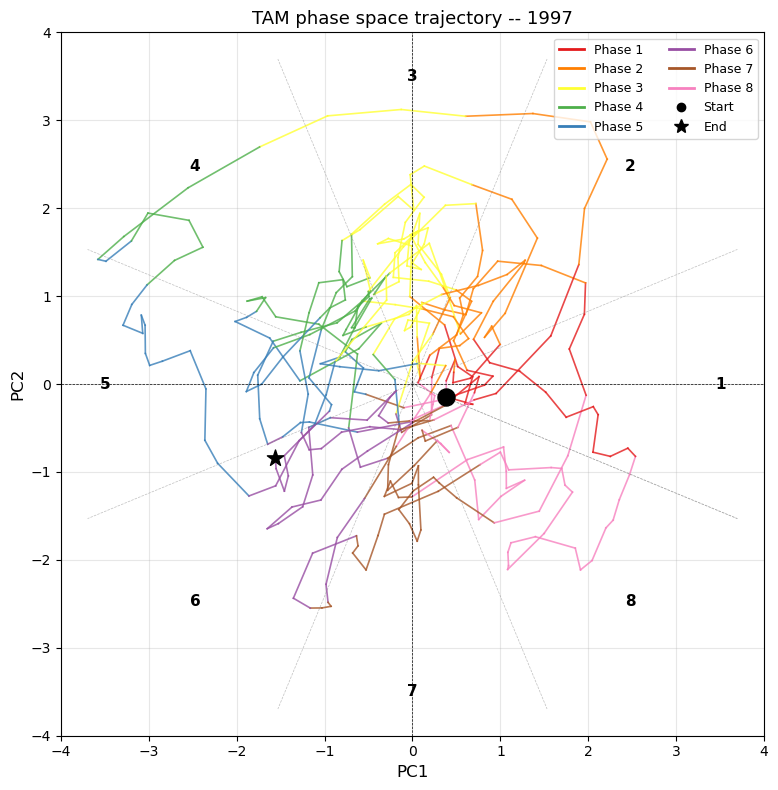

In [23]:
# 8 phase colors
phase_colors = {
    1: '#e41a1c',  # red
    2: '#ff7f00',  # orange
    3: '#ffff33',  # yellow
    4: '#4daf4a',  # green
    5: '#377eb8',  # blue
    6: '#984ea3',  # purple
    7: '#a65628',  # brown
    8: '#f781bf',  # pink
}

fig, ax = plt.subplots(figsize=(8, 8))

# Plot trajectory colored by phase
for t in range(len(idx_1997) - 1):
    p = phase_1997[t]
    ax.plot(pc1_1997[t:t+2], pc2_1997[t:t+2],
            color=phase_colors[p], linewidth=1.2, alpha=0.8)

# Mark start and end points
ax.scatter(pc1_1997[0],  pc2_1997[0],
           s=150, color='k', marker='o', zorder=5, label='Start')
ax.scatter(pc1_1997[-1], pc2_1997[-1],
           s=150, color='k', marker='*', zorder=5, label='End')

# Sector dividing lines at BORDERS (-22.5, 22.5, 67.5, ...)
for angle in np.arange(-22.5, 360, 45):
    rad = np.deg2rad(angle)
    ax.plot([0, 4*np.cos(rad)], [0, 4*np.sin(rad)],
            color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

# Phase labels at CENTERS (0, 45, 90, ...)
for p, angle in enumerate(np.arange(0, 360, 45), start=1):
    rad = np.deg2rad(angle)
    ax.text(3.5*np.cos(rad), 3.5*np.sin(rad), str(p),
            ha='center', va='center', fontsize=11, fontweight='bold')
    
# Legend for phase colors
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=phase_colors[p],
                   linewidth=2, label=f'Phase {p}') for p in range(1, 9)]
legend_elements += [
    Line2D([0], [0], color='k', marker='o', linewidth=0, label='Start'),
    Line2D([0], [0], color='k', marker='*', linewidth=0, markersize=10, label='End')
]
ax.legend(handles=legend_elements, fontsize=9,
          loc='upper right', ncol=2)

ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('TAM phase space trajectory -- 1997', fontsize=13)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('TAM_trajectory_1997.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# Find peak amplitude day in 1997
peak_idx_in_1997 = np.argmax(A_1997)
peak_day = peak_idx_in_1997  # index within 1997
peak_amplitude = A_1997[peak_idx_in_1997]
peak_global_idx = idx_1997[peak_idx_in_1997]  # index in full 16059-day array

print(f"Peak amplitude in 1997: {peak_amplitude:.3f}")
print(f"Day within 1997 (0-indexed): {peak_day}")
print(f"Global index: {peak_global_idx}")

Peak amplitude in 1997: 3.848
Day within 1997 (0-indexed): 318
Global index: 6705


In [27]:
window = 40  # days either side

# Window bounds within 1997 array
win_start = peak_idx_in_1997 - window  # 318 - 40 = 278
win_end   = peak_idx_in_1997 + window  # 318 + 40 = 358

print(f"Window: day {win_start} to day {win_end} within 1997")
print(f"Window length: {win_end - win_start} days")

# Check bounds -- must be within 0 and 364
assert win_start >= 0,   "Window extends before start of 1997"
assert win_end   <= 364, "Window extends past end of 1997"

# Slice PCs for this window
pc1_window = pc1_1997[win_start:win_end]
pc2_window = pc2_1997[win_start:win_end]
phase_window = phase_1997[win_start:win_end]
A_window = A_1997[win_start:win_end]

print(f"Window amplitude mean: {A_window.mean():.3f}")
print(f"Window amplitude max:  {A_window.max():.3f}")

Window: day 278 to day 358 within 1997
Window length: 80 days
Window amplitude mean: 2.047
Window amplitude max:  3.848


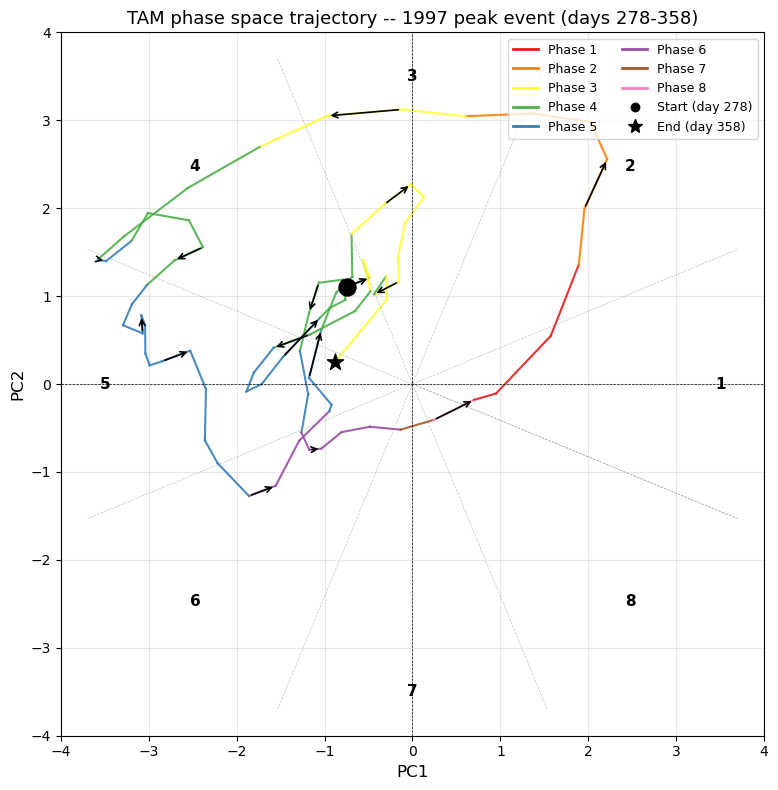

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot trajectory colored by phase
for t in range(len(pc1_window) - 1):
    p = phase_window[t]
    ax.plot(pc1_window[t:t+2], pc2_window[t:t+2],
            color=phase_colors[p], linewidth=1.5, alpha=0.9)

# Arrows every 5 days
arrow_step = 5
for t in range(0, len(pc1_window) - 1, arrow_step):
    ax.annotate('',
        xy=(pc1_window[t+1], pc2_window[t+1]),
        xytext=(pc1_window[t], pc2_window[t]),
        arrowprops=dict(arrowstyle='->', color='k', lw=1.2)
    )

# Start and end points
ax.scatter(pc1_window[0],  pc2_window[0],
           s=150, color='k', marker='o', zorder=5, label='Start (day 278)')
ax.scatter(pc1_window[-1], pc2_window[-1],
           s=150, color='k', marker='*', zorder=5, label='End (day 358)')

# Sector dividing lines at borders
for angle in np.arange(-22.5, 360, 45):
    rad = np.deg2rad(angle)
    ax.plot([0, 4*np.cos(rad)], [0, 4*np.sin(rad)],
            color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

# Phase labels at centers
for p, angle in enumerate(np.arange(0, 360, 45), start=1):
    rad = np.deg2rad(angle)
    ax.text(3.5*np.cos(rad), 3.5*np.sin(rad), str(p),
            ha='center', va='center', fontsize=11, fontweight='bold')

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=phase_colors[p],
                   linewidth=2, label=f'Phase {p}') for p in range(1, 9)]
legend_elements += [
    Line2D([0], [0], color='k', marker='o', linewidth=0, label='Start (day 278)'),
    Line2D([0], [0], color='k', marker='*', linewidth=0, markersize=10, label='End (day 358)')
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right', ncol=2)

ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('TAM phase space trajectory -- 1997 peak event (days 278-358)', fontsize=13)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('TAM_trajectory_1997_peak.png', dpi=300, bbox_inches='tight')
plt.show()

## 2006-07-05

In [29]:
# Find index of 2006 July 5 (DOY 186) in our alltime array
years_coord = tam_trop.coords['year'].values
doy_coord   = tam_trop.coords['time'].values

mask_event = (years_coord == 2006) & (doy_coord == 186)
idx_event  = np.where(mask_event)[0]

print(f"Index of 2006-07-05: {idx_event}")
print(f"Amplitude on that day: {A[idx_event[0]]:.3f}")
print(f"Phase on that day: {phase[idx_event[0]]}")

Index of 2006-07-05: [9857]
Amplitude on that day: 4.034
Phase on that day: 1


Window length: 81 days


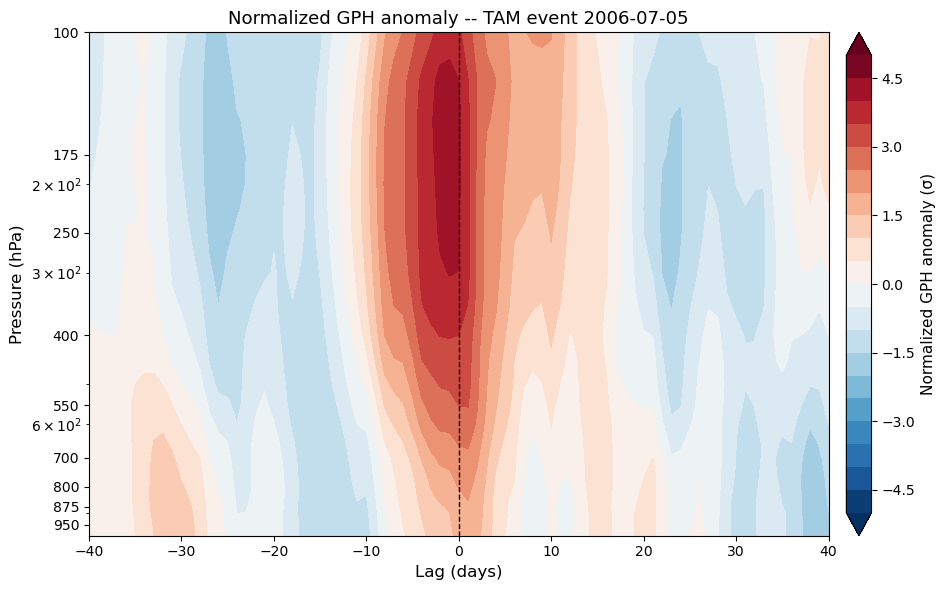

In [30]:
lag = 40
idx_center = 9857

# Window indices in full 16059-day array
win_start = idx_center - lag      # 9817
win_end   = idx_center + lag + 1  # 9898, +1 for inclusive end

print(f"Window length: {win_end - win_start} days")  # should be 81

# Slice tam_trop over the window
tamp_window = tam_trop.isel(alltime=slice(win_start, win_end))  # shape (27, 81)

# Normalize to unit variance at each level over the full record
tamp_std = tam_trop.std(dim='alltime')        # shape (27,)
tamp_window_norm = tamp_window / tamp_std     # shape (27, 81)

lags = np.arange(-lag, lag + 1)  # shape (81,)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

cf = ax.contourf(
    lags,
    tamp_window_norm.level.values,
    tamp_window_norm.values,
    levels=np.arange(-5, 5.5, 0.5),
    cmap='RdBu_r',
    extend='both'
)

ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_xlabel('Lag (days)', fontsize=12)
ax.set_xlim(-40, 40)
ax.set_title('Normalized GPH anomaly -- TAM event 2006-07-05', fontsize=13)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(tam_trop.level.values[::3])

cbar = fig.colorbar(cf, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Normalized GPH anomaly (σ)', fontsize=11)

ax.axvline(0, color='k', linewidth=1, linestyle='--')

plt.tight_layout()
#plt.savefig('TAM_event_20060705_levellag.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# Slice PCs and phase for the same window
pc1_event = PCstrop[0][win_start:win_end]  # shape (81,)
pc2_event = PCstrop[1][win_start:win_end]  # shape (81,)
phase_event = phase[win_start:win_end]      # shape (81,)
A_event = A[win_start:win_end]              # shape (81,)

print(f"Amplitude range in window: {A_event.min():.3f} to {A_event.max():.3f}")
print(f"Amplitude mean in window: {A_event.mean():.3f}")
print(f"Phase at center (lag=0): {phase_event[lag]}")

Amplitude range in window: 0.283 to 4.178
Amplitude mean in window: 1.645
Phase at center (lag=0): 1


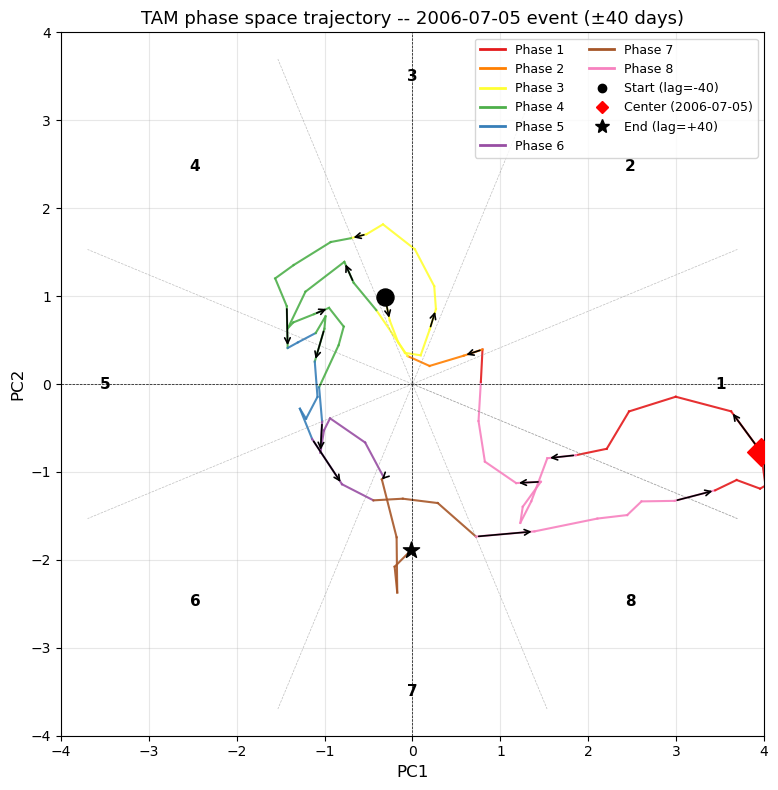

In [32]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot trajectory colored by phase
for t in range(len(pc1_event) - 1):
    p = phase_event[t]
    ax.plot(pc1_event[t:t+2], pc2_event[t:t+2],
            color=phase_colors[p], linewidth=1.5, alpha=0.9)

# Arrows every 5 days
arrow_step = 5
for t in range(0, len(pc1_event) - 1, arrow_step):
    ax.annotate('',
        xy=(pc1_event[t+1], pc2_event[t+1]),
        xytext=(pc1_event[t], pc2_event[t]),
        arrowprops=dict(arrowstyle='->', color='k', lw=1.2)
    )

# Mark start, center (lag=0) and end
ax.scatter(pc1_event[0], pc2_event[0],
           s=150, color='k', marker='o', zorder=5, label='Start (lag=-40)')
ax.scatter(pc1_event[lag], pc2_event[lag],
           s=200, color='r', marker='D', zorder=5, label='Center (2006-07-05)')
ax.scatter(pc1_event[-1], pc2_event[-1],
           s=150, color='k', marker='*', zorder=5, label='End (lag=+40)')

# Sector dividing lines at borders
for angle in np.arange(-22.5, 360, 45):
    rad = np.deg2rad(angle)
    ax.plot([0, 4*np.cos(rad)], [0, 4*np.sin(rad)],
            color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

# Phase labels at centers
for p, angle in enumerate(np.arange(0, 360, 45), start=1):
    rad = np.deg2rad(angle)
    ax.text(3.5*np.cos(rad), 3.5*np.sin(rad), str(p),
            ha='center', va='center', fontsize=11, fontweight='bold')

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=phase_colors[p],
                   linewidth=2, label=f'Phase {p}') for p in range(1, 9)]
legend_elements += [
    Line2D([0], [0], color='k', marker='o', linewidth=0, label='Start (lag=-40)'),
    Line2D([0], [0], color='r', marker='D', linewidth=0, label='Center (2006-07-05)'),
    Line2D([0], [0], color='k', marker='*', linewidth=0, markersize=10, label='End (lag=+40)')
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right', ncol=2)

ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('TAM phase space trajectory -- 2006-07-05 event (±40 days)', fontsize=13)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('TAM_trajectory_20060705.png', dpi=300, bbox_inches='tight')
plt.show()

## First Run at Compositing

In [31]:
print(f"Days with A > 1.0: {np.sum(A > 1.0)} ({np.sum(A > 1.0)/len(A)*100:.1f}%)")
print(f"Days with A > 1.414: {np.sum(A > 1.414)} ({np.sum(A > 1.414)/len(A)*100:.1f}%)")
print(f"Days with A > 1.5: {np.sum(A > 1.5)} ({np.sum(A > 1.5)/len(A)*100:.1f}%)")

Days with A > 1.0: 9688 (60.3%)
Days with A > 1.414: 5907 (36.8%)
Days with A > 1.5: 5223 (32.5%)


In [32]:
for p in range(1, 9):
    mask = (phase == p) & (A > 1.0)       # RMM convention
    # mask = (phase == p) & (A > 1.414)   # sqrt(2) convention
    # mask = (phase == p) & (A > 1.5)     # 1.5 convention
    n_days = np.sum(mask)
    print(f"Phase {p}: {n_days} days ({n_days/np.sum(A > 1.0)*100:.1f}%)")

Phase 1: 1205 days (12.4%)
Phase 2: 1246 days (12.9%)
Phase 3: 1150 days (11.9%)
Phase 4: 1268 days (13.1%)
Phase 5: 1201 days (12.4%)
Phase 6: 1160 days (12.0%)
Phase 7: 1243 days (12.8%)
Phase 8: 1215 days (12.5%)


In [33]:
# Build composites
n_phases = 8
composite = np.zeros((len(tam_trop.level), n_phases))  # shape (27, 8)

for p in range(1, n_phases + 1):
    mask = (phase == p) & (A > 1.0)        # RMM convention
    # mask = (phase == p) & (A > 1.414)    # sqrt(2) convention
    # mask = (phase == p) & (A > 1.5)      # 1.5 convention
    
    # Select active days for this phase and average
    composite[:, p-1] = tam_trop.isel(alltime=mask).mean(dim='alltime').values

# Physical units version (meters): composite as is
composite_physical = composite.copy()

# Normalized version (sigma): divide by std at each level
tamp_std = tam_trop.std(dim='alltime').values  # shape (27,)
composite_norm = composite / tamp_std[:, np.newaxis]  # shape (27, 8)

# Sanity check
print(f"Composite shape: {composite.shape}")
print(f"Physical units range: {composite_physical.min():.2f} to {composite_physical.max():.2f} m")
print(f"Normalized range: {composite_norm.min():.3f} to {composite_norm.max():.3f} sigma")

Composite shape: (27, 8)
Physical units range: -21.90 to 22.73 m
Normalized range: -1.655 to 1.597 sigma


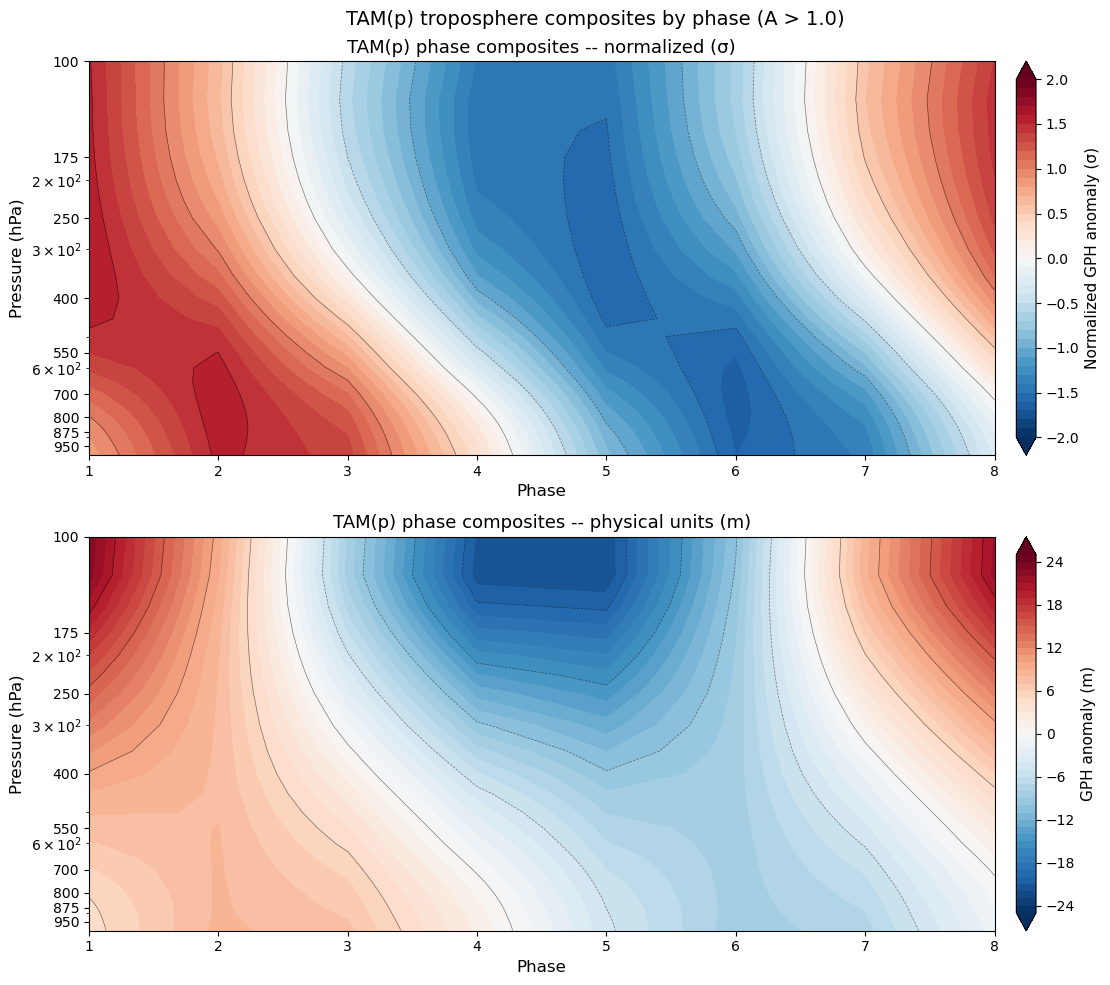

In [34]:
phases = np.arange(1, 9)
levels = tam_trop.level.values

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Normalized version ---
ax = axes[0]
cf1 = ax.contourf(
    phases, levels, composite_norm,
    levels=np.arange(-2, 2.1, 0.1),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases, levels, composite_norm,
    levels=np.arange(-2, 2.1, 0.5),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('TAM(p) phase composites -- normalized (σ)', fontsize=13)
ax.set_xticks(phases)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(levels[::3])
cbar1 = fig.colorbar(cf1, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('Normalized GPH anomaly (σ)', fontsize=11)

# --- Physical units version ---
ax = axes[1]
cf2 = ax.contourf(
    phases, levels, composite_physical,
    levels=np.arange(-25, 26, 1),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases, levels, composite_physical,
    levels=np.arange(-25, 26, 5),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('TAM(p) phase composites -- physical units (m)', fontsize=13)
ax.set_xticks(phases)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(levels[::3])
cbar2 = fig.colorbar(cf2, ax=ax, orientation='vertical', pad=0.02)
cbar2.set_label('GPH anomaly (m)', fontsize=11)

plt.suptitle('TAM(p) troposphere composites by phase (A > 1.0)', fontsize=14)
plt.tight_layout()
#plt.savefig('TAMp_phase_composites.png', dpi=300, bbox_inches='tight')
plt.show()

### Centering composites

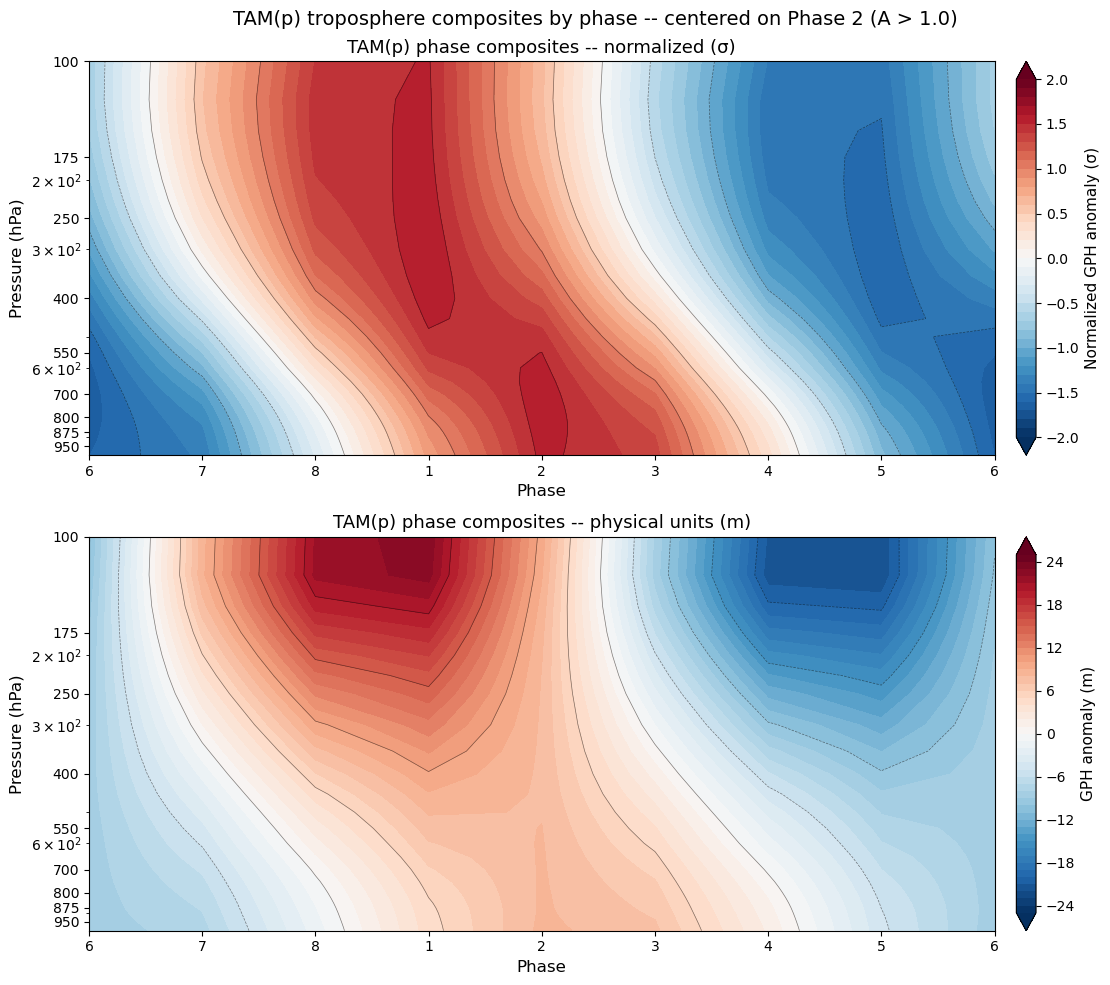

In [35]:
# Reorder phases centered on phase 2
# New order: [6,7,8,1,2,3,4,5,6] = 0-indexed: [5,6,7,0,1,2,3,4,5]
phase_order  = [5, 6, 7, 0, 1, 2, 3, 4, 5]
phase_labels = [6, 7, 8, 1, 2, 3, 4, 5, 6]

composite_norm_centered     = composite_norm[:, phase_order]     # shape (27, 9)
composite_physical_centered = composite_physical[:, phase_order] # shape (27, 9)

phases_centered = np.arange(1, 10)  # 9 columns, x coords for contourf

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Normalized version ---
ax = axes[0]
cf1 = ax.contourf(
    phases_centered, levels, composite_norm_centered,
    levels=np.arange(-2, 2.1, 0.1),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, levels, composite_norm_centered,
    levels=np.arange(-2, 2.1, 0.5),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('TAM(p) phase composites -- normalized (σ)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(levels[::3])
cbar1 = fig.colorbar(cf1, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('Normalized GPH anomaly (σ)', fontsize=11)

# --- Physical units version ---
ax = axes[1]
cf2 = ax.contourf(
    phases_centered, levels, composite_physical_centered,
    levels=np.arange(-25, 26, 1),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, levels, composite_physical_centered,
    levels=np.arange(-25, 26, 5),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('TAM(p) phase composites -- physical units (m)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(levels[::3])
cbar2 = fig.colorbar(cf2, ax=ax, orientation='vertical', pad=0.02)
cbar2.set_label('GPH anomaly (m)', fontsize=11)

plt.suptitle('TAM(p) troposphere composites by phase -- centered on Phase 2 (A > 1.0)', fontsize=14)
plt.tight_layout()
#plt.savefig('TAMp_phase_composites_centered.png', dpi=300, bbox_inches='tight')
plt.show()